# Classificação de textos com spaCy

### Etapa 1: Importação e instalação das bibliotecas

In [1]:
! pip install spacy --upgrade

In [9]:
import pandas as pd
import string
import spacy
import random
import seaborn as sns
import numpy as np

In [10]:
import spacy
spacy.__version__

'3.8.14'

Etapa 2: Carregamento da base de dados

In [11]:
base_dados = pd.read_csv('base_treinamento.csv', encoding='utf-8') 

In [13]:
base_dados.shape

(196, 2)

In [14]:
base_dados.head()

,texto,emocao
0,este trabalho é agradável,alegria
1,gosto de ficar no seu aconchego,alegria
2,fiz a adesão ao curso hoje,alegria
3,eu sou admirada por muitos,alegria
4,adoro como você,alegria


In [15]:
base_dados.tail()

,texto,emocao
191,estou chocado e amedrontado com este assassina...,medo
192,é preciso afugenta com ímpeto este medo do inf...,medo
193,políticos usam suas forças para afugentar e am...,medo
194,o objetivo disso e apenas me amedrontar mais,medo
195,isso me apavora,medo


<Axes: xlabel='count', ylabel='emocao'>

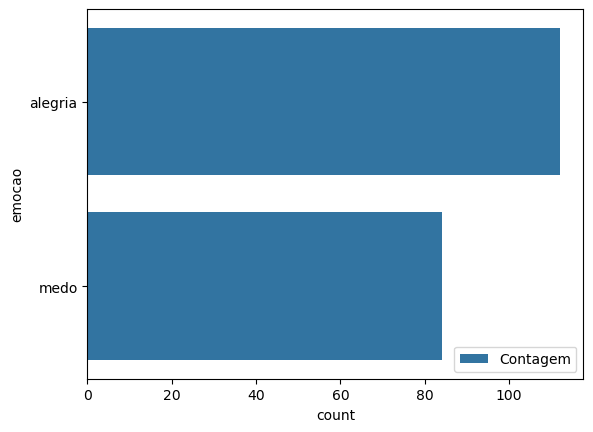

In [16]:
sns.countplot(y='emocao', data=base_dados, label='Contagem')

### Etapa 3: Função para pré-processamento dos textos

In [17]:
pontuacoes = string.punctuation
pontuacoes

'!"#$%&\'()*+,-./:;<=>?@[\\]^_`{|}~'

In [18]:
from spacy.lang.pt.stop_words import STOP_WORDS
stop_words = STOP_WORDS

In [19]:
print(stop_words)

{'esse', 'ambas', 'elas', 'estado', 'dar', 'desde', 'tentei', 'pois', 'diz', 'minha', 'estou', 'outras', 'local', 'dizem', 'em', 'quinta', 'enquanto', 'ou', 'sempre', 'quarta', 'quando', 'vosso', 'foi', 'irá', 'treze', 'apontar', 'segunda', 'muito', 'tuas', 'dezasseis', 'nove', 'entre', 'vais', 'teus', 'dos', 'ambos', 'não', 'vindo', 'obrigada', 'porquê', 'tanta', 'do', 'todos', 'tanto', 'tentaram', 'pouco', 'pela', 'área', 'conhecido', 'cá', 'veja', 'mil', 'num', 'grandes', 'zero', 'estiveram', 'meus', 'cento', 'meses', 'daquele', 'fora', 'que', 'baixo', 'nossos', 'posso', 'certeza', 'sobre', 'meu', 'dizer', 'se', 'saber', 'eles', 'dentro', 'menor', 'vossas', 'aquela', 'aos', 'teu', 'pegar', 'vão', 'cuja', 'vossos', 'seu', 'maiorias', 'vós', 'catorze', 'deve', 'dessa', 'deverá', 'nunca', 'custa', 'também', 'forma', 'des', 'vem', 'assim', 'porquanto', 'seus', 'terceira', 'mesmo', 'alguns', 'oitavo', 'dezoito', 'dão', 'esta', 'ontem', 'parte', 'possível', 'cedo', 'fazer', 'desse', 'acer

In [20]:
len(STOP_WORDS)

416

In [21]:
pln = spacy.load('pt_core_news_sm')

In [22]:
pln

In [23]:
def preprocessamento(texto):
    texto = texto.lower()
    documento = pln(texto)

    lista = []
    for token in documento:
        lista.append(token.lemma_)

    lista = [palavra for palavra in lista if palavra not in stop_words and palavra not in pontuacoes]
    lista = ' '.join([str(elemento) for elemento in lista if not elemento.isdigit()])

    return lista

In [24]:
teste = preprocessamento('Eu estou aPrendendo 1 10 23 processamento de linguagem natural com o spacy!!!')
teste

'aprender processamento linguagem natural spacy'

### Etapa 4: Pré-processamento da base de dados

Limpeza dos textos

In [25]:
base_dados.head()

,texto,emocao
0,este trabalho é agradável,alegria
1,gosto de ficar no seu aconchego,alegria
2,fiz a adesão ao curso hoje,alegria
3,eu sou admirada por muitos,alegria
4,adoro como você,alegria


In [26]:
base_dados['texto'] = base_dados['texto'].apply(preprocessamento)

In [27]:
base_dados.head(10)

,texto,emocao
0,trabalho agradável,alegria
1,gostar ficar em o aconchego,alegria
2,fiz adesão a o curso hoje,alegria
3,admirar,alegria
4,adorar,alegria
5,adorar cabelo macio,alegria
6,adorar cor de o olho,alegria
7,somo amável outro,alegria
8,sinto afeição,alegria
9,querer agradar filho,alegria


Tratamento da classe

In [28]:
exemplo_base_dados = [["este trabalho é agradável", {"ALEGRIA": True, "MEDO": False}],
                      ["este lugar continua assustador", {"ALEGRIA": False, "MEDO": True}]]

In [29]:
type(exemplo_base_dados)

list

In [30]:
exemplo_base_dados[0]

['este trabalho é agradável', {'ALEGRIA': True, 'MEDO': False}]

In [31]:
exemplo_base_dados[0][0]

'este trabalho é agradável'

In [32]:
exemplo_base_dados[0][1]

{'ALEGRIA': True, 'MEDO': False}

In [33]:
type(exemplo_base_dados[0][1])

dict

In [35]:
base_dados_final = []
for texto, emocao in zip(base_dados['texto'], base_dados['emocao']):
  #print(texto, emocao)
  if emocao == 'alegria':
    dic = ({'ALEGRIA': True, 'MEDO': False})
  elif emocao == 'medo':
    dic = ({'ALEGRIA': False, 'MEDO': True})

  base_dados_final.append([texto, dic.copy()])

In [37]:
len(base_dados_final)

196

In [38]:
base_dados_final[0]

['trabalho agradável', {'ALEGRIA': True, 'MEDO': False}]

In [39]:
base_dados_final[0][0]

'trabalho agradável'

In [40]:
base_dados_final[0][1]

{'ALEGRIA': True, 'MEDO': False}

In [41]:
type(base_dados_final[0][1])

dict

In [66]:
base_dados_final = []
for texto, emocao in zip(base_dados['texto'], base_dados['emocao']):
  #print(texto, emocao)
  if emocao == 'alegria':
    dic = ({'ALEGRIA': True, 'MEDO': False})
  elif emocao == 'medo':
    dic = ({'ALEGRIA': False, 'MEDO': True})

  base_dados_final.append([texto, dic.copy()])


In [67]:
len(base_dados_final)

196

In [68]:
base_dados_final[0]

['trabalho agradável', {'ALEGRIA': True, 'MEDO': False}]

In [70]:
base_dados_final[0][0]

'trabalho agradável'

In [71]:
base_dados_final[0][1]

{'ALEGRIA': True, 'MEDO': False}

In [72]:
type(exemplo_base_dados[0][1])

dict

In [73]:
base_dados_final

[['trabalho agradável', {'ALEGRIA': True, 'MEDO': False}],
 ['gostar ficar em o aconchego', {'ALEGRIA': True, 'MEDO': False}],
 ['fiz adesão a o curso hoje', {'ALEGRIA': True, 'MEDO': False}],
 ['admirar', {'ALEGRIA': True, 'MEDO': False}],
 ['adorar', {'ALEGRIA': True, 'MEDO': False}],
 ['adorar cabelo macio', {'ALEGRIA': True, 'MEDO': False}],
 ['adorar cor de o olho', {'ALEGRIA': True, 'MEDO': False}],
 ['somo amável outro', {'ALEGRIA': True, 'MEDO': False}],
 ['sinto afeição', {'ALEGRIA': True, 'MEDO': False}],
 ['querer agradar filho', {'ALEGRIA': True, 'MEDO': False}],
 ['sinto completamente amar', {'ALEGRIA': True, 'MEDO': False}],
 ['amar', {'ALEGRIA': True, 'MEDO': False}],
 ['alívio', {'ALEGRIA': True, 'MEDO': False}],
 ['dor amenizar finalmente', {'ALEGRIA': True, 'MEDO': False}],
 ['achar apaixonar', {'ALEGRIA': True, 'MEDO': False}],
 ['amar maravilhoso', {'ALEGRIA': True, 'MEDO': False}],
 ['sentir animar', {'ALEGRIA': True, 'MEDO': False}],
 ['sinto hoje', {'ALEGRIA': Tr

### Etapa 5: Criação do classificados

In [74]:
from spacy.training import Example

In [75]:
modelo = spacy.blank('pt')
textcat = modelo.add_pipe('textcat')
textcat.add_label('ALEGRIA')
textcat.add_label('MEDO')
historico = []

In [76]:
modelo.begin_training()
for epoca in range(1000):
  random.shuffle(base_dados_final)
  losses = {}
  for batch in spacy.util.minibatch(base_dados_final, 30):
    textos = [modelo(texto) for texto, entities in batch]
    annotations = [{'cats': entities} for texto, entities in batch]
    examples = [Example.from_dict(doc, annotation) for doc, annotation in zip(
            textos, annotations
        )]
    modelo.update(examples, losses=losses)
  if epoca % 100 == 0:
    print(losses)
    historico.append(losses)

{'textcat': 1.7223424166440964}
{'textcat': 4.110350026922255e-11}
{'textcat': 5.308385133372118e-12}
{'textcat': 1.3619364899633384e-12}
{'textcat': 5.159312647246006e-13}
{'textcat': 2.436765660128806e-13}
{'textcat': 9.687980881187123e-14}
{'textcat': 6.135226883618333e-14}
{'textcat': 2.644451663228679e-14}
{'textcat': 1.606466800600789e-14}


In [78]:
historico_loss = []
for i in historico:
  historico_loss.append(i.get('textcat'))

In [79]:
historico_loss = np.array(historico_loss)
historico_loss

array([1.72234242e+00, 4.11035003e-11, 5.30838513e-12, 1.36193649e-12,
       5.15931265e-13, 2.43676566e-13, 9.68798088e-14, 6.13522688e-14,
       2.64445166e-14, 1.60646680e-14])

Text(0, 0.5, 'Erro')

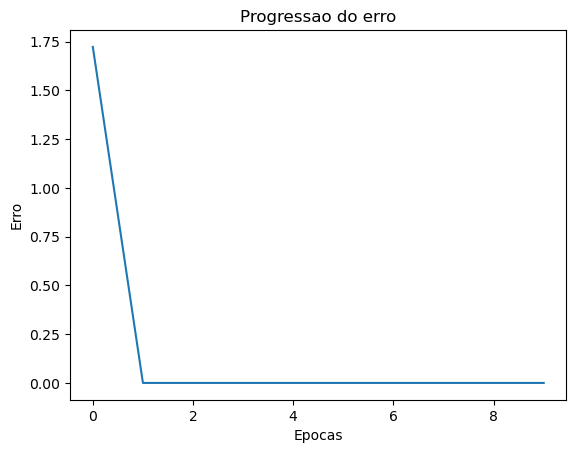

In [80]:
import matplotlib.pyplot as plt
plt.plot(historico_loss)
plt.title('Progressao do erro')
plt.xlabel('Epocas')
plt.ylabel('Erro')

In [82]:
modelo.to_disk('modelo')

### Etapa 6: Testes com uma frase

In [83]:
modelo_carregado = spacy.load('modelo')
modelo_carregado

In [85]:
texto_positivo = 'eu adoro a cor dos seus olhos'

In [86]:
texto_positivo = preprocessamento(texto_positivo)
texto_positivo

'adorar cor de o olho'

In [87]:
previsao = modelo_carregado(texto_positivo)
previsao

adorar cor de o olho

In [88]:
previsao.cats

{'ALEGRIA': 1.0, 'MEDO': 1.8074150176516923e-08}

In [89]:
texto_negativo = 'estou com medo dele'
previsao = modelo_carregado(preprocessamento(texto_negativo))
previsao.cats

{'ALEGRIA': 3.602607634434207e-08, 'MEDO': 1.0}

### Etapa 7: Avaliação do modelo

Avaliação na base de treinamento

In [90]:
previsoes = []
for texto in base_dados['texto']:
  previsao = modelo_carregado(texto)
  previsoes.append(previsao.cats)

In [91]:
previsoes

[{'ALEGRIA': 1.0, 'MEDO': 2.3125393155964957e-08},
 {'ALEGRIA': 1.0, 'MEDO': 4.138232512218565e-08},
 {'ALEGRIA': 1.0, 'MEDO': 1.716538378104815e-08},
 {'ALEGRIA': 1.0, 'MEDO': 1.0903781877402707e-08},
 {'ALEGRIA': 1.0, 'MEDO': 2.623379735666731e-09},
 {'ALEGRIA': 1.0, 'MEDO': 8.762137682083448e-09},
 {'ALEGRIA': 1.0, 'MEDO': 1.8074150176516923e-08},
 {'ALEGRIA': 1.0, 'MEDO': 5.075067122106702e-08},
 {'ALEGRIA': 1.0, 'MEDO': 1.0340540868014614e-08},
 {'ALEGRIA': 1.0, 'MEDO': 4.940823572496811e-08},
 {'ALEGRIA': 1.0, 'MEDO': 6.709865552068095e-09},
 {'ALEGRIA': 1.0, 'MEDO': 1.8430947434922018e-08},
 {'ALEGRIA': 1.0, 'MEDO': 1.2378456037964725e-09},
 {'ALEGRIA': 1.0, 'MEDO': 3.157479966375831e-08},
 {'ALEGRIA': 0.9999997615814209, 'MEDO': 2.5469230990893266e-07},
 {'ALEGRIA': 1.0, 'MEDO': 1.1626338114467671e-08},
 {'ALEGRIA': 1.0, 'MEDO': 1.9958202202019493e-08},
 {'ALEGRIA': 1.0, 'MEDO': 3.0910964898822613e-09},
 {'ALEGRIA': 1.0, 'MEDO': 9.837416214963923e-09},
 {'ALEGRIA': 1.0, 'MEDO':

In [92]:
previsoes_final = []
for previsao in previsoes:
  if previsao['ALEGRIA']>previsao['MEDO']:
    previsoes_final.append('alegria')
else:
    previsoes_final.append('medo')

previsoes_final = np.array(previsoes_final)

In [93]:
previsoes_final = []
for previsao in previsoes:
    if previsao['ALEGRIA'] > previsao['MEDO']:
        previsoes_final.append('alegria')
    else:
        previsoes_final.append('medo')

previsoes_final = np.array(previsoes_final)

In [94]:
previsoes_final

array(['alegria', 'alegria', 'alegria', 'alegria', 'alegria', 'alegria',
       'alegria', 'alegria', 'alegria', 'alegria', 'alegria', 'alegria',
       'alegria', 'alegria', 'alegria', 'alegria', 'alegria', 'alegria',
       'alegria', 'alegria', 'alegria', 'alegria', 'alegria', 'alegria',
       'alegria', 'alegria', 'alegria', 'alegria', 'alegria', 'alegria',
       'alegria', 'alegria', 'alegria', 'alegria', 'alegria', 'alegria',
       'alegria', 'alegria', 'alegria', 'alegria', 'alegria', 'alegria',
       'alegria', 'alegria', 'alegria', 'alegria', 'alegria', 'alegria',
       'alegria', 'alegria', 'alegria', 'alegria', 'alegria', 'alegria',
       'alegria', 'alegria', 'alegria', 'alegria', 'alegria', 'alegria',
       'alegria', 'alegria', 'alegria', 'alegria', 'alegria', 'alegria',
       'alegria', 'alegria', 'alegria', 'alegria', 'alegria', 'alegria',
       'alegria', 'alegria', 'alegria', 'alegria', 'alegria', 'alegria',
       'alegria', 'alegria', 'alegria', 'alegria', 

In [95]:
respostas_reais = base_dados['emocao'].values
respostas_reais

array(['alegria', 'alegria', 'alegria', 'alegria', 'alegria', 'alegria',
       'alegria', 'alegria', 'alegria', 'alegria', 'alegria', 'alegria',
       'alegria', 'alegria', 'alegria', 'alegria', 'alegria', 'alegria',
       'alegria', 'alegria', 'alegria', 'alegria', 'alegria', 'alegria',
       'alegria', 'alegria', 'alegria', 'alegria', 'alegria', 'alegria',
       'alegria', 'alegria', 'alegria', 'alegria', 'alegria', 'alegria',
       'alegria', 'alegria', 'alegria', 'alegria', 'alegria', 'alegria',
       'alegria', 'alegria', 'alegria', 'alegria', 'alegria', 'alegria',
       'alegria', 'alegria', 'alegria', 'alegria', 'alegria', 'alegria',
       'alegria', 'alegria', 'alegria', 'alegria', 'alegria', 'alegria',
       'alegria', 'alegria', 'alegria', 'alegria', 'alegria', 'alegria',
       'alegria', 'alegria', 'alegria', 'alegria', 'alegria', 'alegria',
       'alegria', 'alegria', 'alegria', 'alegria', 'alegria', 'alegria',
       'alegria', 'alegria', 'alegria', 'alegria', 

In [96]:
from sklearn.metrics import confusion_matrix, accuracy_score
accuracy_score(respostas_reais, previsoes_final)

1.0

In [97]:
cm = confusion_matrix(respostas_reais, previsoes_final)
cm

array([[112,   0],
       [  0,  84]])

### Avaliação na base de teste

In [103]:
base_dados_teste = pd.read_csv('base_teste.txt', encoding='utf-8')

In [104]:
base_dados_teste.head()

,texto,emocao
0,não precisei pagar o ingresso,alegria
1,se eu ajeitar tudo fica bem,alegria
2,minha fortuna ultrapassará a sua,alegria
3,sou muito afortunado,alegria
4,é benéfico para todos esta nova medida,alegria


In [105]:
base_dados_teste['texto'] = base_dados_teste['texto'].apply(preprocessamento)

In [106]:
base_dados_teste.head()

,texto,emocao
0,precisar pagar ingresso,alegria
1,ajeitar ficar,alegria
2,fortuna ultrapassar,alegria
3,afortunar,alegria
4,benéfico medida,alegria
